# Customer Segmentation Analysis

**Dataset:** UCI "Online Retail" — transactions from a UK-based online retailer, Dec 2010–Dec 2011.
**Goal:** Segment customers into distinct groups based on purchasing behavior (RFM analysis + K-Means clustering) to enable targeted marketing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load and inspect the dataset

In [2]:
df = pd.read_excel("data/online_retail.xlsx")
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

**Observations:** `CustomerID` is missing for ~135k rows (guest/unidentified transactions) — these can't be
attributed to a customer, so they're dropped. `Description` has a small number of missing values, irrelevant
to this analysis (not used). We also need to remove cancelled orders (InvoiceNo starting with 'C') and any
non-positive Quantity/UnitPrice, since those aren't genuine purchases.

In [5]:
df_clean = df.dropna(subset=["CustomerID"]).copy()
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean.shape

(397884, 9)

## 2. Descriptive statistics

In [6]:
order_value = df_clean.groupby("InvoiceNo")["TotalPrice"].sum()
purchase_freq = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()

print("Average order value: £%.2f" % order_value.mean())
print("Average purchase frequency per customer:", round(purchase_freq.mean(), 2))
print("Average customer lifetime value (total spend): £%.2f" % df_clean.groupby("CustomerID")["TotalPrice"].sum().mean())

Average order value: £480.87
Average purchase frequency per customer: 4.27
Average customer lifetime value (total spend): £2054.27


## 3. RFM feature engineering

**Recency** — days since the customer's last purchase (relative to one day after the dataset's last date).
**Frequency** — number of distinct invoices (orders) placed by the customer.
**Monetary** — total amount spent by the customer.

These three features are the standard basis for customer-value segmentation (RFM analysis).

In [7]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


## 4. Standardize features before clustering

In [8]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

## 5. K-Means with the Elbow Method

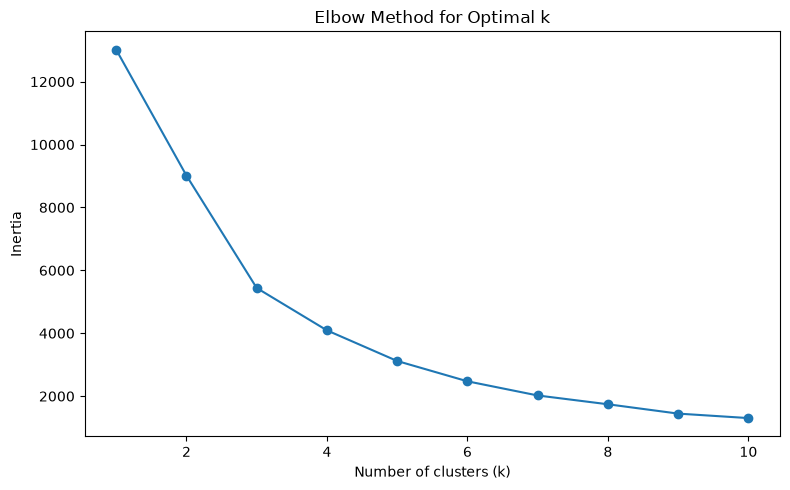

In [9]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig("outputs/01_elbow_method.png")
plt.show()

**Reading the elbow chart:** inertia drops sharply up to around k=4, after which additional clusters
yield diminishing reductions. k=4 is chosen as the optimal number of segments.

In [10]:
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

## 6. Visualize the clusters

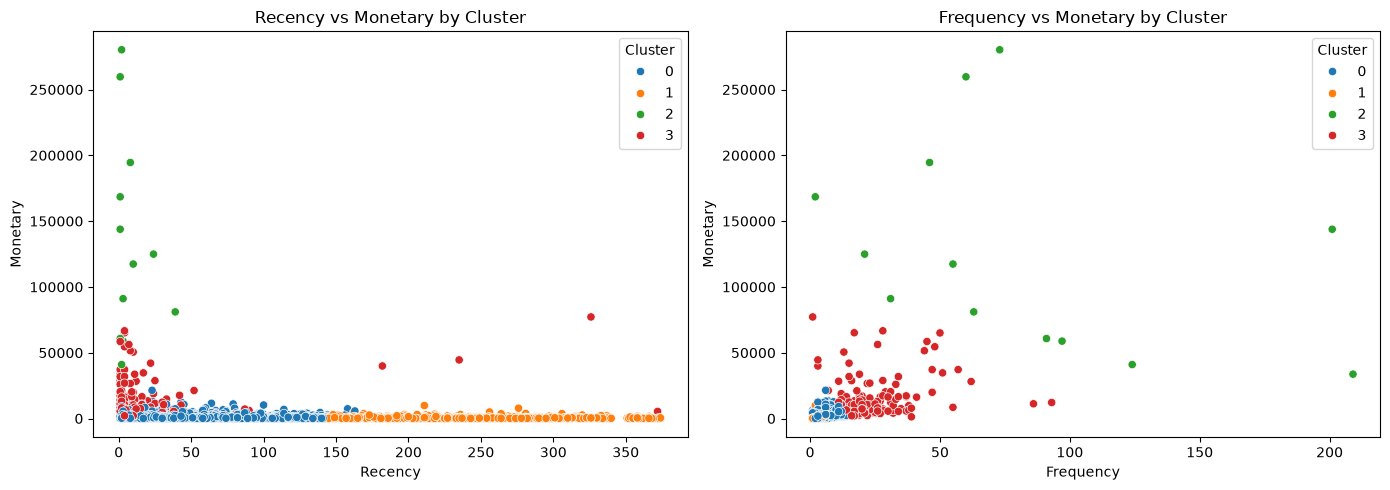

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="tab10", ax=axes[0])
axes[0].set_title("Recency vs Monetary by Cluster")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="tab10", ax=axes[1])
axes[1].set_title("Frequency vs Monetary by Cluster")

plt.tight_layout()
plt.savefig("outputs/02_cluster_scatter.png")
plt.show()

## 7. Cluster profiling

In [12]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile.to_csv("outputs/cluster_profile.csv")
cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.70,3.68,1359.05,3054
1,248.08,1.55,480.62,1067
2,7.38,82.54,127338.31,13
3,15.50,22.33,12709.09,204


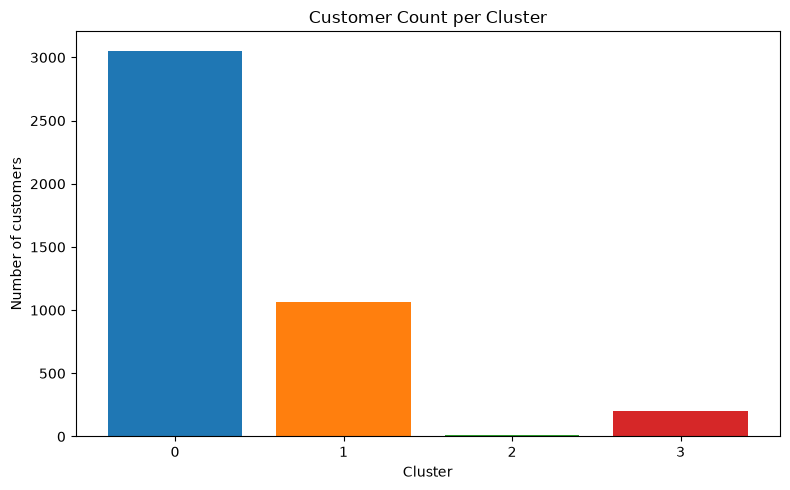

In [13]:
plt.bar(cluster_profile.index.astype(str), cluster_profile["CustomerCount"], color=sns.color_palette("tab10"))
plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.title("Customer Count per Cluster")
plt.tight_layout()
plt.savefig("outputs/03_customers_per_cluster.png")
plt.show()

## 8. Cluster interpretation & marketing recommendations

Based on the mean Recency/Frequency/Monetary values per cluster above, each segment can be labeled and
targeted differently:

- **High-value / frequent / recent buyers** — the most profitable segment. Recommendation: enroll in a
  loyalty/VIP program, offer early access to new products, prioritize retention over acquisition spend.
- **High spend but infrequent / less recent** — customers who spend well when they do buy but are drifting
  away. Recommendation: targeted win-back email campaigns with personalized offers based on past purchases.
- **Frequent but low monetary value** — regular small-basket shoppers. Recommendation: upsell/cross-sell
  campaigns (bundle deals) to increase average order value without needing new customer acquisition.
- **Low frequency, low monetary, high recency (haven't purchased in a long time)** — at-risk / low-engagement
  customers. Recommendation: re-engagement campaigns (discount codes) or deprioritize marketing spend if
  response rates stay low, since acquisition cost may exceed their likely lifetime value.

Exact cluster-to-label mapping should be read off the `cluster_profile` table above for this specific run,
since K-Means cluster indices are not inherently ordered by value.